Task 0 — Setup & Dataset Loading

In [ ]:

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, MobileNetV2
import os, tarfile, time, re

tf.random.set_seed(42)
np.random.seed(42)

IMG_SIZE = 224
BATCH_SIZE = 32

DATA_DIR = "/content/oxford_pets"
os.makedirs(DATA_DIR, exist_ok=True)
images_url = "https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz"
images_path = tf.keras.utils.get_file("images.tar.gz", images_url, cache_dir=DATA_DIR, extract=False)

if not os.path.exists(os.path.join(DATA_DIR, "images")):
    print("Extracting images...")
    with tarfile.open(images_path) as tar:
        tar.extractall(path=DATA_DIR)

img_dir = os.path.join(DATA_DIR, "images")
all_files = [f for f in os.listdir(img_dir) if f.endswith('.jpg')]
print("Total images found:", len(all_files))
def get_breed(fname):
    return re.sub(r'_\d+\.jpg$', '', fname)

breeds = sorted(set(get_breed(f) for f in all_files))
class_names = breeds
NUM_CLASSES = len(class_names)
breed_to_idx = {b: i for i, b in enumerate(breeds)}
print("Number of classes:", NUM_CLASSES)

labels = np.array([breed_to_idx[get_breed(f)] for f in all_files])
filepaths = np.array([os.path.join(img_dir, f) for f in all_files])
rng = np.random.default_rng(42)
perm = rng.permutation(len(filepaths))
filepaths, labels = filepaths[perm], labels[perm]

n = len(filepaths)
n_train = int(0.7 * n)
n_val = int(0.15 * n)

train_files, train_labels = filepaths[:n_train], labels[:n_train]
val_files, val_labels     = filepaths[n_train:n_train+n_val], labels[n_train:n_train+n_val]
test_files, test_labels   = filepaths[n_train+n_val:], labels[n_train+n_val:]

print(f"Train: {len(train_files)}, Val: {len(val_files)}, Test: {len(test_files)}")

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = preprocess_input(img)
    return img, label

def make_ds(files, labels, batch_size=BATCH_SIZE, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((files, labels))
    if shuffle:
        ds = ds.shuffle(1000, seed=42)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_ds(train_files, train_labels, shuffle=True)
val_ds   = make_ds(val_files, val_labels)
test_ds  = make_ds(test_files, test_labels)

print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Val batches:  ", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches: ", tf.data.experimental.cardinality(test_ds).numpy())

def get_mobilenet_base(trainable=False, unfreeze_from=None):
    base = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                        include_top=False,
                        weights='imagenet',
                        pooling='avg')
    base.trainable = trainable
    if trainable and unfreeze_from is not None:
        for layer in base.layers[:unfreeze_from]:
            layer.trainable = False
    return base

791918971/791918971 ━━━━━━━━━━━━━━━━━━━━ 41s 0us/step
Extracting images...


/tmp/ipykernel_1336/2597665648.py:22: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=DATA_DIR)


Total images found: 7390
Number of classes: 37
Train: 5173, Val: 1108, Test: 1109
Train batches: 162
Val batches:   35
Test batches:  35


Task 1 — Weight Initialization Comparison (Plots 1 & 2)


--- Training with Zero initialization ---
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 65s 287ms/step - accuracy: 0.0267 - loss: 3.6113 - val_accuracy: 0.0208 - val_loss: 3.6119
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - accuracy: 0.0284 - loss: 3.6109 - val_accuracy: 0.0208 - val_loss: 3.6127
Epoch 3/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 93ms/step - accuracy: 0.0275 - loss: 3.6108 - val_accuracy: 0.0226 - val_loss: 3.6136
Epoch 4/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 21s 95ms/step - accuracy: 0.0278 - loss: 3.6106 - val_accuracy: 0.0126 - val_loss: 3.6141
Epoch 5/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 20s 94ms/step - accuracy: 0.0298 - loss: 3.6105 - val_accuracy: 0.0208 - val_loss: 3.6148

--- Training with Random initialization ---
Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 36s 171ms/step - accuracy: 0.7703 - loss: 0.9583 - val_accuracy: 0.8926 - val_loss: 0.3685
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 92ms/step - accuracy: 0.9217 - loss: 0.2453 

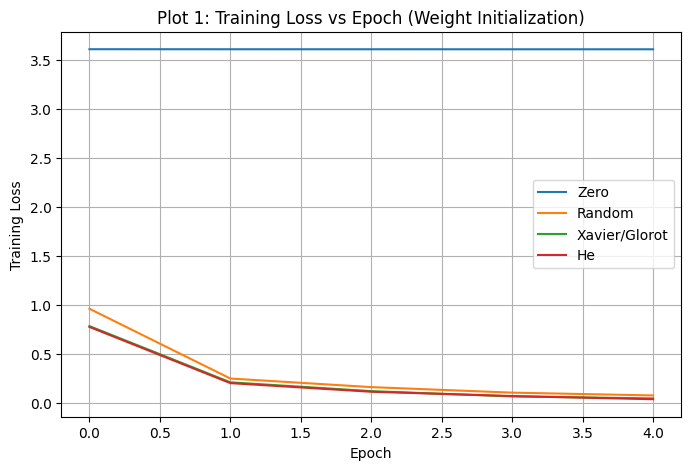

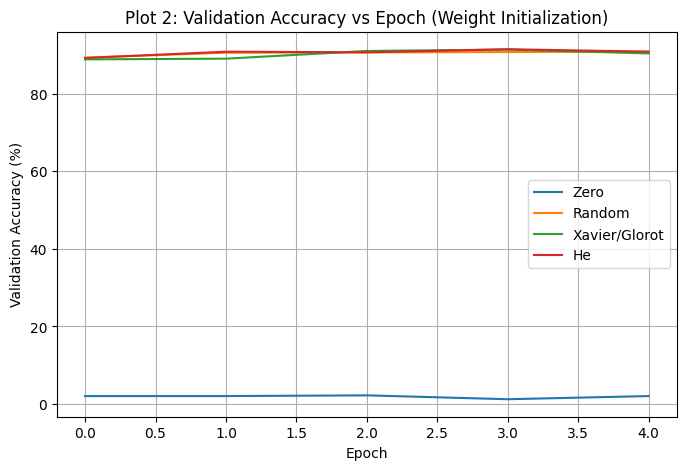

In [ ]:

from tensorflow.keras.initializers import Zeros, RandomNormal, GlorotUniform, HeUniform

initializers = {
    "Zero": Zeros(),
    "Random": RandomNormal(mean=0.0, stddev=0.05, seed=42),
    "Xavier/Glorot": GlorotUniform(seed=42),
    "He": HeUniform(seed=42)
}

def build_model_with_init(kernel_init):
    base = get_mobilenet_base(trainable=False)
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.Dense(128, activation='relu', kernel_initializer=kernel_init)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax', kernel_initializer=kernel_init)(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

EPOCHS = 5
init_histories = {}

for name, init in initializers.items():
    print(f"\n--- Training with {name} initialization ---")
    model = build_model_with_init(init)
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=1)
    init_histories[name] = history.history
plt.figure(figsize=(8,5))
for name, hist in init_histories.items():
    plt.plot(hist['loss'], label=name)
plt.xlabel('Epoch'); plt.ylabel('Training Loss')
plt.title('Plot 1: Training Loss vs Epoch (Weight Initialization)')
plt.legend(); plt.grid(True); plt.show()
plt.figure(figsize=(8,5))
for name, hist in init_histories.items():
    plt.plot([a*100 for a in hist['val_accuracy']], label=name)
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 2: Validation Accuracy vs Epoch (Weight Initialization)')
plt.legend(); plt.grid(True); plt.show()

Task 3 — Batch Normalization: With vs Without (Plot 5 + numerical example)

Batch mean (mu_B): 5.0
Batch variance (sigma_B^2): 5.0
Normalized activations (x_hat): [-1.3416407 -0.4472136  0.4472136  1.3416407]
Final BN output (gamma=1, beta=0): [-1.3416407 -0.4472136  0.4472136  1.3416407]

--- Training With BN ---
Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 38s 175ms/step - accuracy: 0.7914 - loss: 0.9429 - val_accuracy: 0.8944 - val_loss: 0.3977
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 93ms/step - accuracy: 0.9412 - loss: 0.2624 - val_accuracy: 0.8989 - val_loss: 0.3299
Epoch 3/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 93ms/step - accuracy: 0.9745 - loss: 0.1341 - val_accuracy: 0.9134 - val_loss: 0.2924
Epoch 4/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 93ms/step - accuracy: 0.9865 - loss: 0.0741 - val_accuracy: 0.9106 - val_loss: 0.3043
Epoch 5/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 93ms/step - accuracy: 0.9950 - loss: 0.0433 - val_accuracy: 0.9097 - val_loss: 0.2935

--- Training Without BN ---
Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 36s 172ms/step - accuracy: 0.7827 - loss: 0.82

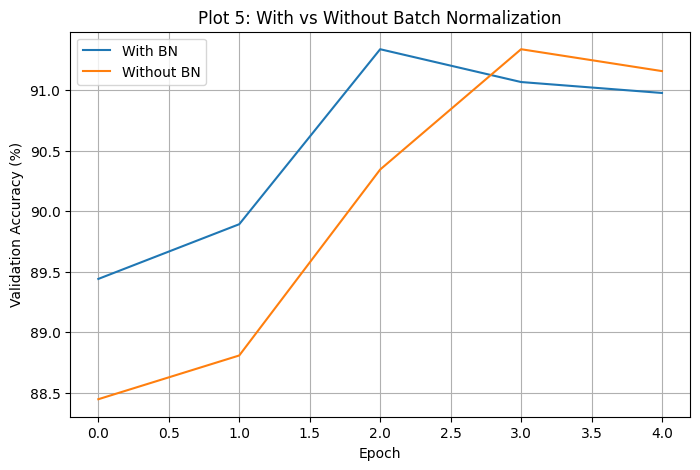

In [ ]:

x = np.array([2, 4, 6, 8], dtype=np.float32)
mu = np.mean(x)
var = np.var(x)
x_hat = (x - mu) / np.sqrt(var + 1e-8)
print("Batch mean (mu_B):", mu)
print("Batch variance (sigma_B^2):", var)
print("Normalized activations (x_hat):", x_hat)
gamma, beta = 1.0, 0.0
y = gamma * x_hat + beta
print("Final BN output (gamma=1, beta=0):", y)

def build_model_bn(use_bn):
    base = get_mobilenet_base(trainable=False)
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.Dense(128, activation='relu')(x)
    if use_bn:
        x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x) if use_bn else x
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

EPOCHS = 5
bn_histories = {}
for use_bn, name in [(True, "With BN"), (False, "Without BN")]:
    print(f"\n--- Training {name} ---")
    model = build_model_bn(use_bn)
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=1)
    bn_histories[name] = history.history
plt.figure(figsize=(8,5))
for name, hist in bn_histories.items():
    plt.plot([a*100 for a in hist['val_accuracy']], label=name)
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 5: With vs Without Batch Normalization')
plt.legend(); plt.grid(True); plt.show()

Task 4 — Optimizer Comparison (Plots 6 & 7 + table)


--- Training with SGD ---
Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 37s 174ms/step - accuracy: 0.3396 - loss: 2.6707 - val_accuracy: 0.7563 - val_loss: 1.4407
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 24s 97ms/step - accuracy: 0.7205 - loss: 1.1831 - val_accuracy: 0.8655 - val_loss: 0.6778
Epoch 3/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 18s 109ms/step - accuracy: 0.7955 - loss: 0.7651 - val_accuracy: 0.8709 - val_loss: 0.5000
Epoch 4/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 95ms/step - accuracy: 0.8399 - loss: 0.5897 - val_accuracy: 0.8890 - val_loss: 0.4174
Epoch 5/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 92ms/step - accuracy: 0.8556 - loss: 0.5063 - val_accuracy: 0.8998 - val_loss: 0.3683

--- Training with Momentum ---
Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 38s 179ms/step - accuracy: 0.6886 - loss: 1.1256 - val_accuracy: 0.8818 - val_loss: 0.3638
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 93ms/step - accuracy: 0.8830 - loss: 0.3669 - val_accuracy: 0.8935 - val_loss: 0.3380
Epoch 3/5
162/162 ━━━━━━━━━━━━━━━━━

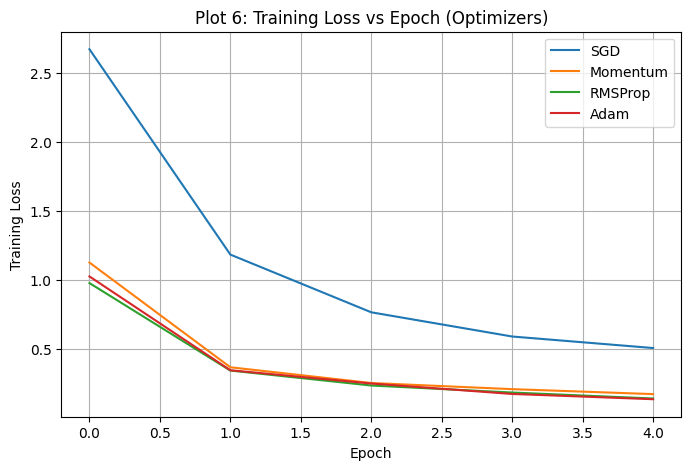

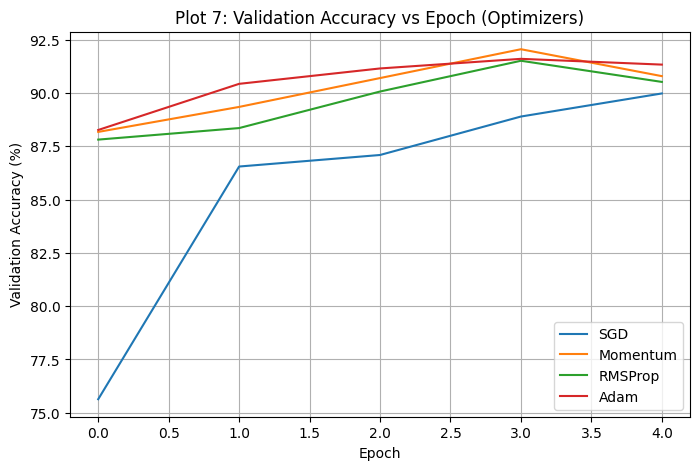

Optimizer  Final Loss  Best Val. Accuracy  Epoch to Converge  Time (s)
      SGD      0.5063               89.98                  5     114.5
 Momentum      0.1726               92.06                  4     106.5
  RMSProp      0.1406               91.52                  4     108.5
     Adam      0.1355               91.61                  4     109.6


In [ ]:

import pandas as pd

def build_base_model():
    base = get_mobilenet_base(trainable=False)
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return models.Model(inputs, outputs)

opt_configs = {
    "SGD": optimizers.SGD(learning_rate=0.01),
    "Momentum": optimizers.SGD(learning_rate=0.01, momentum=0.9),
    "RMSProp": optimizers.RMSprop(learning_rate=0.001),
    "Adam": optimizers.Adam(learning_rate=0.001)
}

EPOCHS = 5
opt_histories = {}
opt_results = []

for name, opt in opt_configs.items():
    print(f"\n--- Training with {name} ---")
    model = build_base_model()
    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    start = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=1)
    elapsed = time.time() - start
    opt_histories[name] = history.history

    best_val_acc = max(history.history['val_accuracy'])
    converge_epoch = history.history['val_accuracy'].index(best_val_acc) + 1
    opt_results.append({
        "Optimizer": name,
        "Final Loss": round(history.history['loss'][-1], 4),
        "Best Val. Accuracy": round(best_val_acc*100, 2),
        "Epoch to Converge": converge_epoch,
        "Time (s)": round(elapsed, 1)
    })

plt.figure(figsize=(8,5))
for name, hist in opt_histories.items():
    plt.plot(hist['loss'], label=name)
plt.xlabel('Epoch'); plt.ylabel('Training Loss')
plt.title('Plot 6: Training Loss vs Epoch (Optimizers)')
plt.legend(); plt.grid(True); plt.show()
plt.figure(figsize=(8,5))
for name, hist in opt_histories.items():
    plt.plot([a*100 for a in hist['val_accuracy']], label=name)
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 7: Validation Accuracy vs Epoch (Optimizers)')
plt.legend(); plt.grid(True); plt.show()
df_opt = pd.DataFrame(opt_results)
print(df_opt.to_string(index=False))

Task 5 — CNN Hyperparameter Tuning (Plots 8, 9, 10)


--- Learning Rate: 0.001 ---
Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 39s 176ms/step - accuracy: 0.7079 - loss: 1.0755 - val_accuracy: 0.8917 - val_loss: 0.3431
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - accuracy: 0.8927 - loss: 0.3433 - val_accuracy: 0.9152 - val_loss: 0.2705
Epoch 3/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 20s 94ms/step - accuracy: 0.9217 - loss: 0.2544 - val_accuracy: 0.9088 - val_loss: 0.2810
Epoch 4/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 92ms/step - accuracy: 0.9441 - loss: 0.1740 - val_accuracy: 0.9179 - val_loss: 0.2636
Epoch 5/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 23s 110ms/step - accuracy: 0.9582 - loss: 0.1323 - val_accuracy: 0.9188 - val_loss: 0.2624

--- Learning Rate: 0.0001 ---
Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 38s 177ms/step - accuracy: 0.2770 - loss: 2.8875 - val_accuracy: 0.6850 - val_loss: 1.7681
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - accuracy: 0.6752 - loss: 1.3830 - val_accuracy: 0.8493 - val_loss: 0.7977
Epoch 3/5
162/162 ━━━━━━━━━━━━━━━

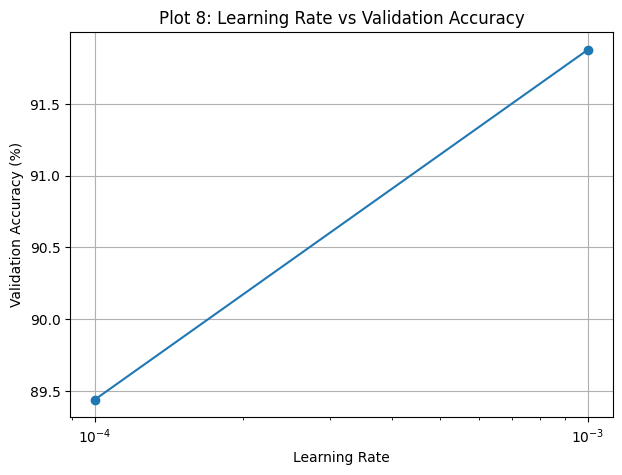


--- Batch Size: 16 ---
Epoch 1/5
324/324 ━━━━━━━━━━━━━━━━━━━━ 65s 146ms/step - accuracy: 0.7404 - loss: 0.9506 - val_accuracy: 0.8980 - val_loss: 0.3450
Epoch 2/5
324/324 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.8981 - loss: 0.3310 - val_accuracy: 0.8926 - val_loss: 0.3333
Epoch 3/5
324/324 ━━━━━━━━━━━━━━━━━━━━ 16s 49ms/step - accuracy: 0.9277 - loss: 0.2245 - val_accuracy: 0.9007 - val_loss: 0.3218
Epoch 4/5
324/324 ━━━━━━━━━━━━━━━━━━━━ 21s 50ms/step - accuracy: 0.9408 - loss: 0.1742 - val_accuracy: 0.9106 - val_loss: 0.2932
Epoch 5/5
324/324 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - accuracy: 0.9534 - loss: 0.1417 - val_accuracy: 0.8971 - val_loss: 0.3171

--- Batch Size: 32 ---
Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 39s 175ms/step - accuracy: 0.7180 - loss: 1.0078 - val_accuracy: 0.8863 - val_loss: 0.3658
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - accuracy: 0.8910 - loss: 0.3410 - val_accuracy: 0.8980 - val_loss: 0.3170
Epoch 3/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 21s 95ms

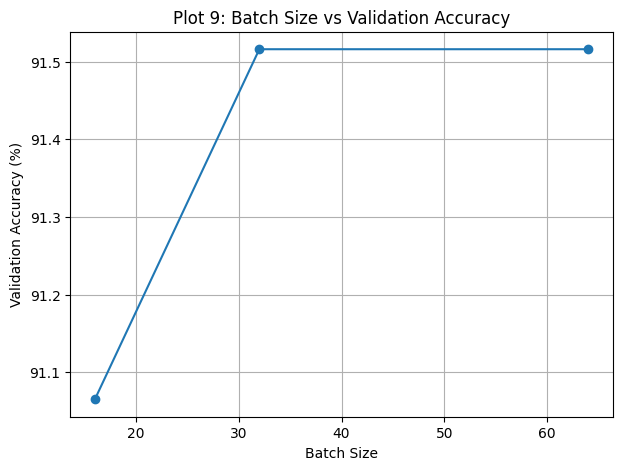


--- Dropout Rate: 0 ---
Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 37s 172ms/step - accuracy: 0.7798 - loss: 0.8191 - val_accuracy: 0.8899 - val_loss: 0.3511
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 95ms/step - accuracy: 0.9341 - loss: 0.2037 - val_accuracy: 0.9097 - val_loss: 0.3042
Epoch 3/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 16s 97ms/step - accuracy: 0.9579 - loss: 0.1278 - val_accuracy: 0.8953 - val_loss: 0.3271
Epoch 4/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 20s 94ms/step - accuracy: 0.9832 - loss: 0.0722 - val_accuracy: 0.9170 - val_loss: 0.3006
Epoch 5/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 23s 108ms/step - accuracy: 0.9919 - loss: 0.0441 - val_accuracy: 0.9025 - val_loss: 0.3097

--- Dropout Rate: 0.25 ---
Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 38s 174ms/step - accuracy: 0.7253 - loss: 1.0044 - val_accuracy: 0.9106 - val_loss: 0.3164
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 93ms/step - accuracy: 0.8919 - loss: 0.3305 - val_accuracy: 0.9016 - val_loss: 0.2936
Epoch 3/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 15

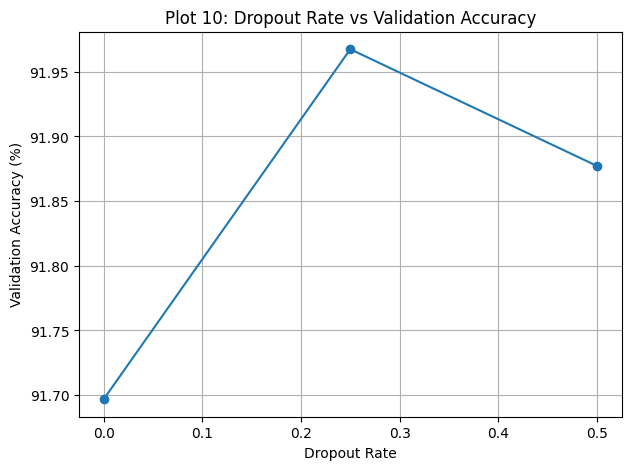

In [ ]:
# TASK 5 (CORRECTED for non-tfds loader): CNN HYPERPARAMETER TUNING
# Learning Rate, Batch Size, Dropout Rate — one hyperparameter changed at a time

def build_hp_model(dropout_rate=0.3):
    base = get_mobilenet_base(trainable=False)
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return models.Model(inputs, outputs)

EPOCHS = 5

# --- 5a. Learning Rate sweep ---
lr_values = [0.001, 0.0001]
lr_results = {}
for lr in lr_values:
    print(f"\n--- Learning Rate: {lr} ---")
    model = build_hp_model(dropout_rate=0.3)
    model.compile(optimizer=optimizers.Adam(learning_rate=lr),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=1)
    lr_results[lr] = max(history.history['val_accuracy']) * 100

plt.figure(figsize=(7,5))
plt.plot(list(lr_results.keys()), list(lr_results.values()), marker='o')
plt.xlabel('Learning Rate'); plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 8: Learning Rate vs Validation Accuracy')
plt.xscale('log'); plt.grid(True); plt.show()

# --- 5b. Batch Size sweep ---
# NOTE: uses make_ds() (file-based loader) instead of prepare_dataset() (tfds-based)
batch_values = [16, 32, 64]
bs_results = {}
for bs in batch_values:
    print(f"\n--- Batch Size: {bs} ---")
    train_ds_bs = make_ds(train_files, train_labels, batch_size=bs, shuffle=True)
    val_ds_bs = make_ds(val_files, val_labels, batch_size=bs)
    model = build_hp_model(dropout_rate=0.3)
    model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(train_ds_bs, validation_data=val_ds_bs, epochs=EPOCHS, verbose=1)
    bs_results[bs] = max(history.history['val_accuracy']) * 100

plt.figure(figsize=(7,5))
plt.plot(list(bs_results.keys()), list(bs_results.values()), marker='o')
plt.xlabel('Batch Size'); plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 9: Batch Size vs Validation Accuracy')
plt.grid(True); plt.show()

# --- 5c. Dropout Rate sweep ---
dropout_values = [0, 0.25, 0.5]
do_results = {}
for dr in dropout_values:
    print(f"\n--- Dropout Rate: {dr} ---")
    model = build_hp_model(dropout_rate=dr)
    model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=1)
    do_results[dr] = max(history.history['val_accuracy']) * 100

plt.figure(figsize=(7,5))
plt.plot(list(do_results.keys()), list(do_results.values()), marker='o')
plt.xlabel('Dropout Rate'); plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 10: Dropout Rate vs Validation Accuracy')
plt.grid(True); plt.show()

Task 6 — Transfer Learning (Feature Extraction) vs Fine-Tuning (Plots 11 & 12)

--- Case A: Feature Extraction ---
Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 38s 174ms/step - accuracy: 0.7176 - loss: 1.0390 - val_accuracy: 0.8755 - val_loss: 0.3586
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 93ms/step - accuracy: 0.8875 - loss: 0.3467 - val_accuracy: 0.9106 - val_loss: 0.2916
Epoch 3/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 20s 92ms/step - accuracy: 0.9291 - loss: 0.2316 - val_accuracy: 0.8881 - val_loss: 0.3356
Epoch 4/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step - accuracy: 0.9403 - loss: 0.1859 - val_accuracy: 0.9007 - val_loss: 0.2909
Epoch 5/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 20s 93ms/step - accuracy: 0.9548 - loss: 0.1403 - val_accuracy: 0.9070 - val_loss: 0.2972

--- Case B: Fine-Tuning ---
Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 49s 201ms/step - accuracy: 0.0762 - loss: 3.5292 - val_accuracy: 0.2644 - val_loss: 2.9507
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 16s 94ms/step - accuracy: 0.2983 - loss: 2.7542 - val_accuracy: 0.5875 - val_loss: 2.1734
Epoch 3/5
162/162 ━━━━━━━━━━━━━

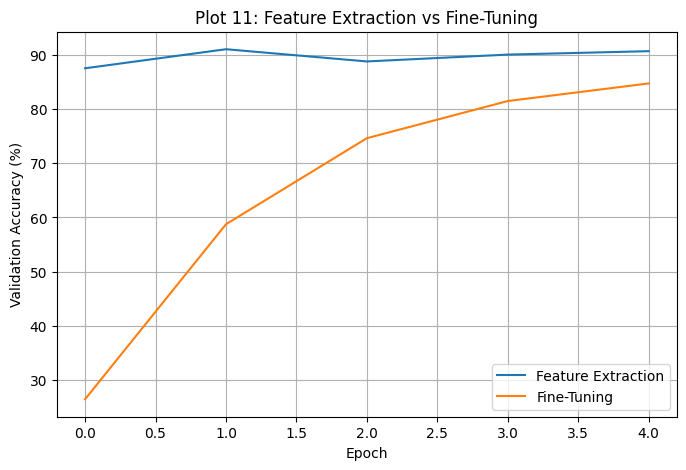

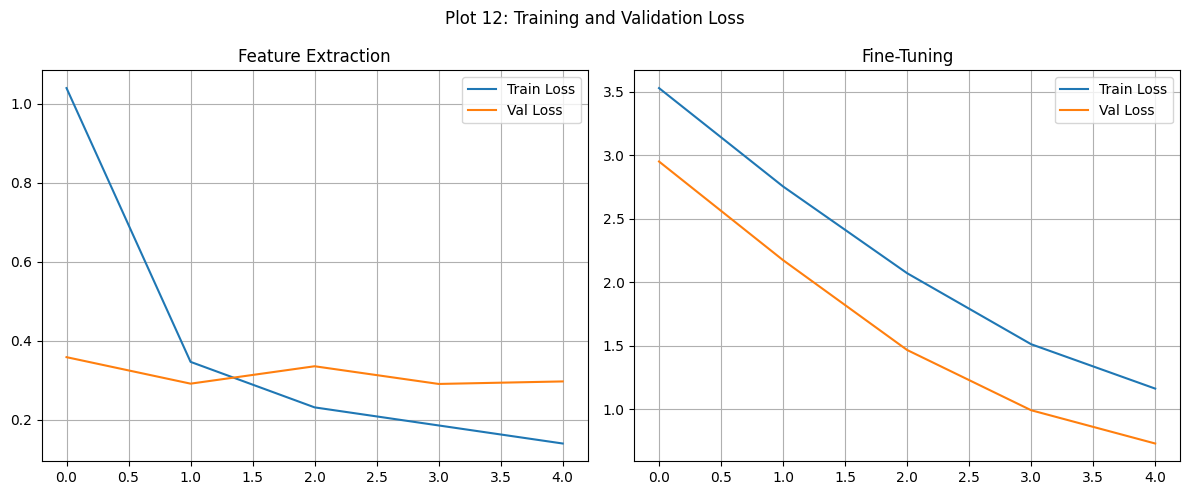

In [ ]:

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
base_fe = get_mobilenet_base(trainable=False)
x = base_fe(inputs, training=False)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model_fe = models.Model(inputs, outputs)
model_fe.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("--- Case A: Feature Extraction ---")
EPOCHS = 5
history_fe = model_fe.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=1)
inputs2 = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
base_ft = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False,
                       weights='imagenet', pooling='avg')
base_ft.trainable = True
for layer in base_ft.layers[:-30]:
    layer.trainable = False

x2 = base_ft(inputs2, training=True)
x2 = layers.Dense(128, activation='relu')(x2)
x2 = layers.Dropout(0.3)(x2)
outputs2 = layers.Dense(NUM_CLASSES, activation='softmax')(x2)
model_ft = models.Model(inputs2, outputs2)
model_ft.compile(optimizer=optimizers.Adam(learning_rate=1e-5),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("\n--- Case B: Fine-Tuning ---")
history_ft = model_ft.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=1)
plt.figure(figsize=(8,5))
plt.plot([a*100 for a in history_fe.history['val_accuracy']], label='Feature Extraction')
plt.plot([a*100 for a in history_ft.history['val_accuracy']], label='Fine-Tuning')
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 11: Feature Extraction vs Fine-Tuning')
plt.legend(); plt.grid(True); plt.show()
fig, axes = plt.subplots(1, 2, figsize=(12,5))
axes[0].plot(history_fe.history['loss'], label='Train Loss')
axes[0].plot(history_fe.history['val_loss'], label='Val Loss')
axes[0].set_title('Feature Extraction'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(history_ft.history['loss'], label='Train Loss')
axes[1].plot(history_ft.history['val_loss'], label='Val Loss')
axes[1].set_title('Fine-Tuning'); axes[1].legend(); axes[1].grid(True)
plt.suptitle('Plot 12: Training and Validation Loss')
plt.tight_layout(); plt.show()